### The goal of this notebook is to test various simulation methods, as well as to cluster final conformations to compare methods.

In [1]:
import numpy as np  # Numerical operations and array manipulations
import matplotlib.pyplot as plt  # Plotting and data visualization
import pandas as pd  # Data structures for handling data (e.g., DataFrame)
import visualization_functions as vis # our functions for visualization
import sim_methods as sim # our functions for simulation

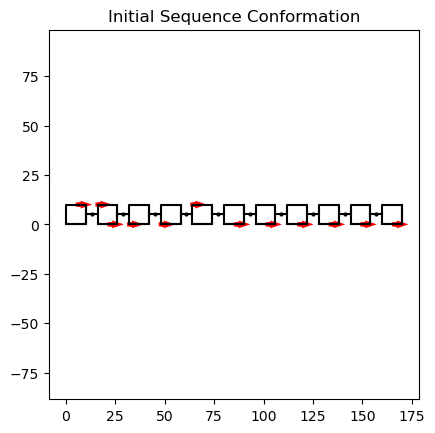

In [2]:
shapes = {'shape 1': ['s', 10, 0, 0, {'patch 1': ['top right', 4, 0]}], 'shape 2':['s', 10, 6, 0, {'patch 1': ['top left', 4, 0], 'patch 2': ['bottom right', 4, 0]}], 'shape 3': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0]}], 
          'shape 4': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0]}], 'shape 5': ['s', 10, 6, 0, {'patch 1': ['top left', 4, 0]}], 'shape 6': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 7': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 8': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 9': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 10': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 11': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}]}

hinge_vec, hinge_loc, shape_arr, linelist, patch_arr, patch_num = vis.generate(shapes)

vis.shapeplots(shape_arr, linelist, hinge_loc, blocking = False, title = 'Initial Sequence Conformation', show = True, bounds = '', mag_vecs = patch_arr)

# Define the magnetization/length of each patch. This is defined from experimental measured values as mentioned in the manuscript
m = np.array([1.01e-6]*sum(patch_num)) # Can change the values of the moments here if we do patches of different sizes

# Establish the magnetic vector containing all of the magnetizations/shape of each magnetic domain (ends of the patches), necessary for energy calculation
magvec = np.repeat(m, 2) # the endpoints are the domains we care about, so this is just a 2n-dim array of the same values as m, where n is the dim of m

mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat = vis.initialize_energy(magvec)

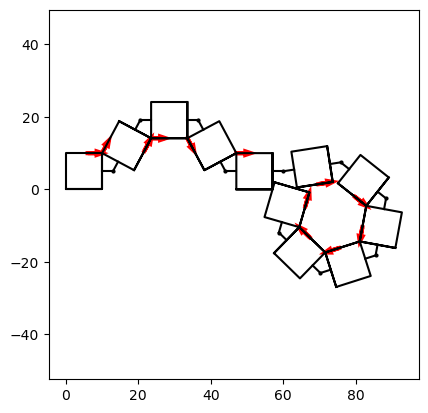

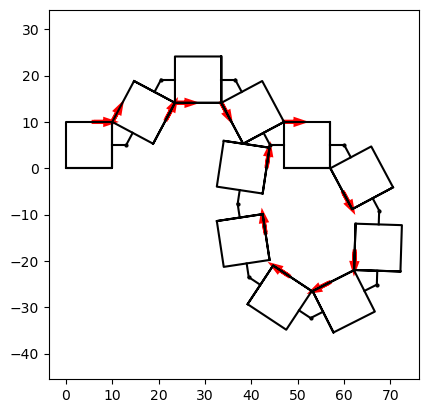

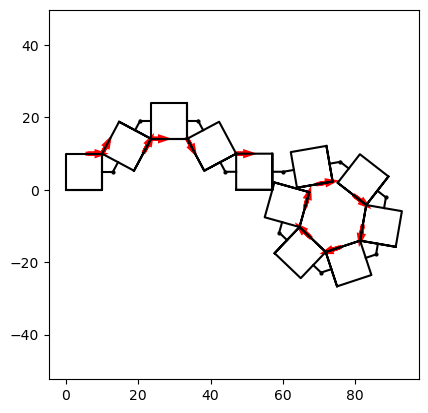

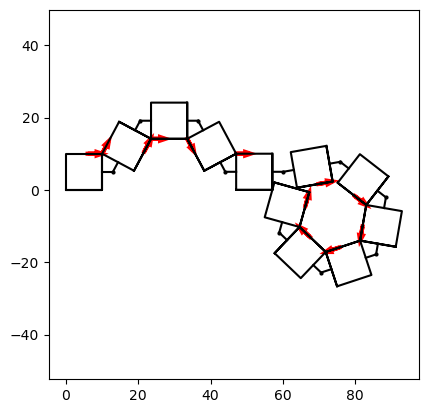

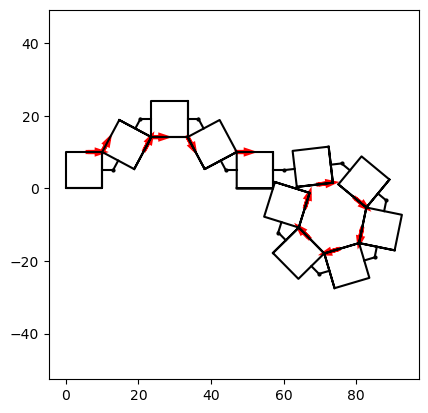

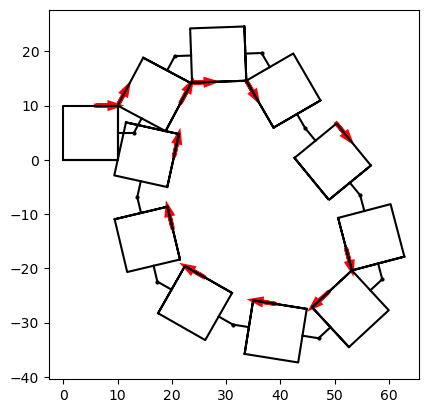

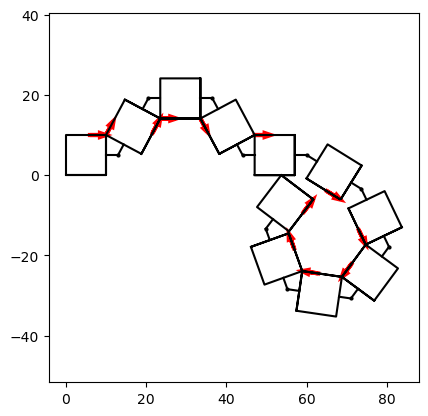

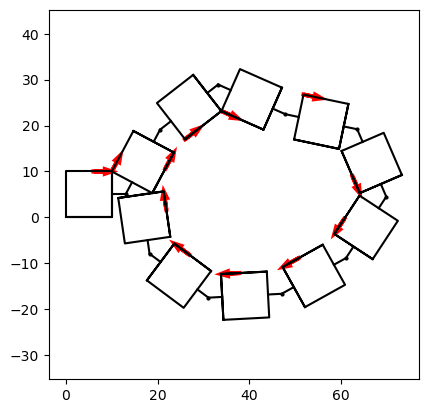

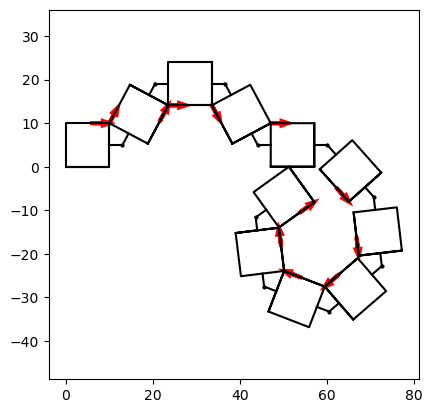

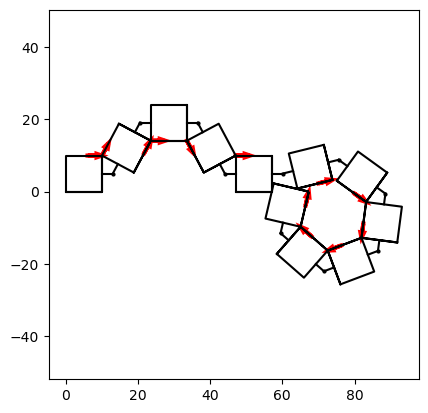

In [27]:
# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 10 # number of simulations
final_hinges, final_es = sim.sim_many(nsim, 'monte carlo',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False, plot=True)

### Running each method 1000 times and clustering to compare results

#### Greedy Descent

In [4]:
# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 1000 # number of simulations
final_hinges_gd, final_es_gd = sim.sim_many(nsim, 'greedy descent',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False)

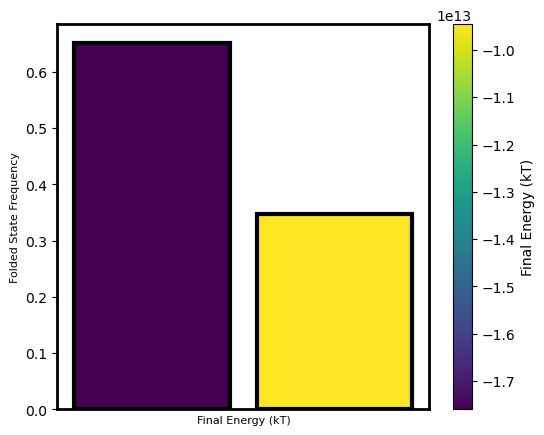

In [6]:
cluster_max_gd = 6
states_gd = 10 #A cluster parameter that allows the KMeans clustering to try out different initial states for better optimization
clusternumber_gd = vis.cluster_num(final_hinges_gd,cluster_max_gd,states_gd, Plot = False)
clustercenters_gd, cluster_labels_gd, clusternumber_gd = vis.min_cluster_centers(final_hinges_gd, clusternumber_gd, final_es_gd)
clusternumbers_gd, cluster_count_gd, cluster_prob_gd, energies_gd, ordered_centers_gd, all_stds_gd = vis.cluster_stats(final_hinges_gd, clusternumber_gd, clustercenters_gd, cluster_labels_gd,
                                                                                                    final_es_gd, plot=True)

#### Monte Carlo

In [6]:
# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 1000 # number of simulations
final_hinges_mc, final_es_mc = sim.sim_many(nsim, 'monte carlo',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False)

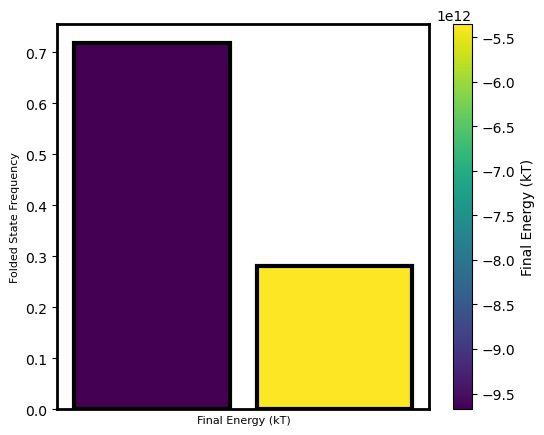

In [5]:
cluster_max_mc = 6
states_mc = 10 #A cluster parameter that allows the KMeans clustering to try out different initial states for better optimization
clusternumber_mc = vis.cluster_num(final_hinges_mc,cluster_max_mc,states_mc, Plot = False)
clustercenters_mc, cluster_labels_mc, clusternumber_mc = vis.min_cluster_centers(final_hinges_mc, clusternumber_mc, final_es_mc)
clusternumbers_mc, cluster_count_mc, cluster_prob_mc, energies_mc, ordered_centers_mc, all_stds_mc = vis.cluster_stats(final_hinges_mc, clusternumber_mc, clustercenters_mc, cluster_labels_mc,
                                                                                                    final_es_mc, plot=True)

#### Weighted Sync

In [8]:
# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 1000 # number of simulations
final_hinges_ws, final_es_ws = sim.sim_many(nsim, 'weighted sync',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False)

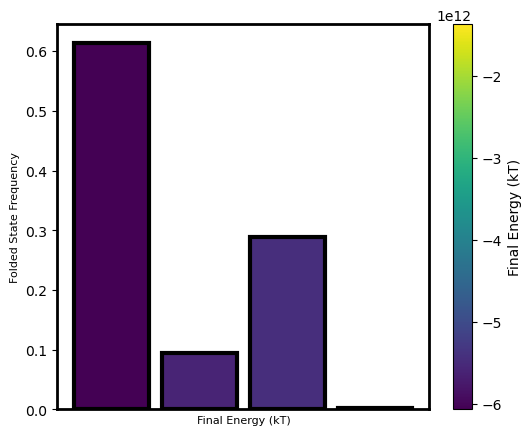

In [4]:
cluster_max_ws = 6
states_ws = 10 #A cluster parameter that allows the KMeans clustering to try out different initial states for better optimization
clusternumber_ws = vis.cluster_num(final_hinges_ws,cluster_max_ws,states_ws, Plot = False)
clustercenters_ws, cluster_labels_ws, clusternumber_ws = vis.min_cluster_centers(final_hinges_ws, clusternumber_ws, final_es_ws)
clusternumbers_ws, cluster_count_ws, cluster_prob_ws, energies_ws, ordered_centers_ws, all_stds_ws = vis.cluster_stats(final_hinges_ws, clusternumber_ws, clustercenters_ws, cluster_labels_ws,
                                                                                                    final_es_ws, plot=True)

### Checking structures of clusters

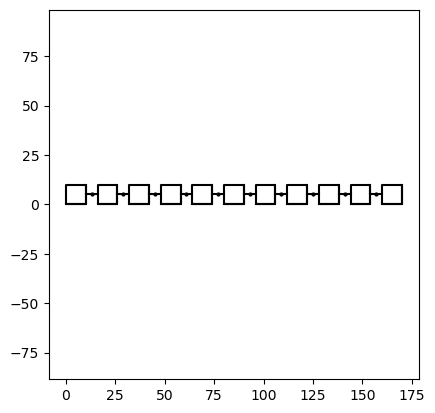

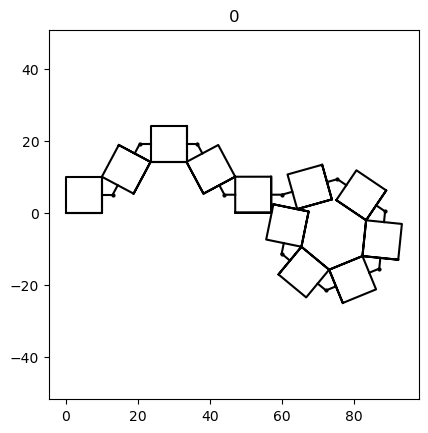

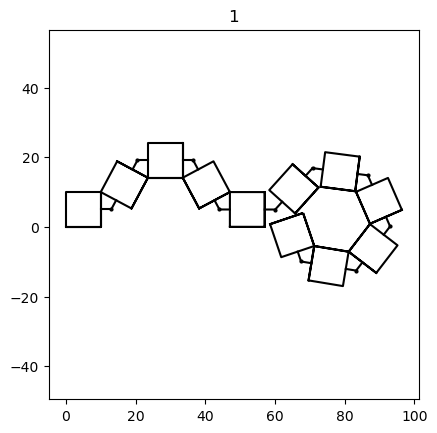

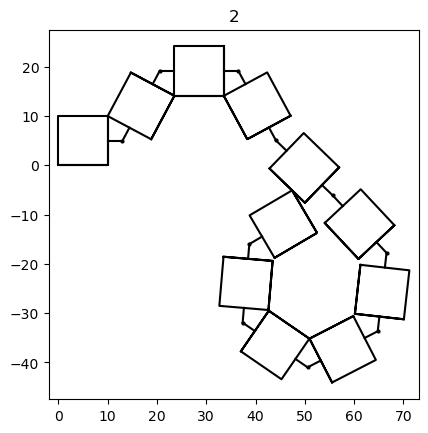

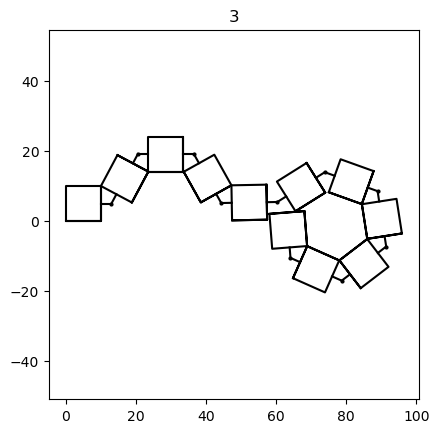

In [37]:
hinges=[0,1,2,3,4,5,6,7,8,9]
vis.show_probable_structures(hinges, shapes, clustercenters_ws)

### Saving of data

In [53]:
# save all data
np.save("final_hinges_gd",final_hinges_gd)
np.save("final_hinges_mc",final_hinges_mc)
np.save("final_hinges_ws",final_hinges_ws)

np.save("final_es_gd", final_es_gd)
np.save("final_es_mc", final_es_mc)
np.save("final_es_ws", final_es_ws)

In [3]:
final_hinges_gd = np.load("final_hinges_gd.npy")
final_hinges_mc = np.load("final_hinges_mc.npy")
final_hinges_ws = np.load("final_hinges_ws.npy")

final_es_gd = np.load("final_es_gd.npy")
final_es_mc = np.load("final_es_mc.npy")
final_es_ws = np.load("final_es_ws.npy")

### Saving energy vs. time step for single runs to compare:

In [ ]:
# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 3 # number of simulations
final_hinges_gd, final_es_gd, energies_gd = sim.sim_many(nsim, 'greedy descent',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False)

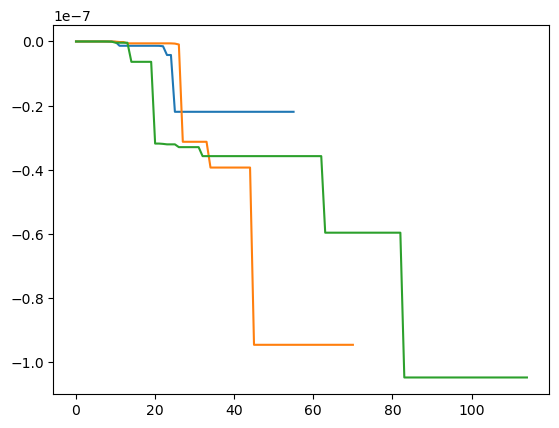

In [ ]:
for i in range(len(energies_gd)):
    plt.plot(energies_gd[i])


In [ ]:
# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 3 # number of simulations
final_hinges_mc, final_es_mc, energies_mc = sim.sim_many(nsim, 'monte carlo',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False)

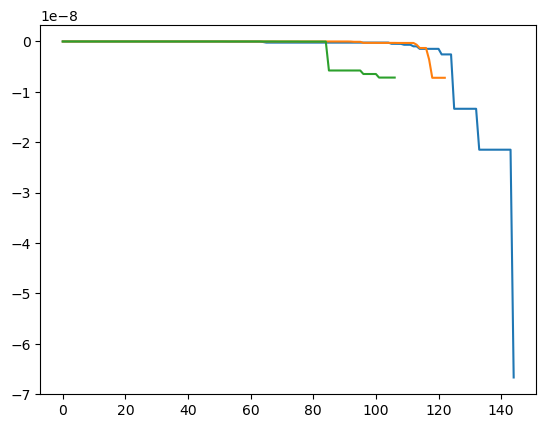

In [ ]:
for i in range(len(energies_mc)):
    plt.plot(energies_mc[i])


In [ ]:
# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 3 # number of simulations
final_hinges_ws, final_es_ws, energies_ws = sim.sim_many(nsim, 'weighted sync',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False)

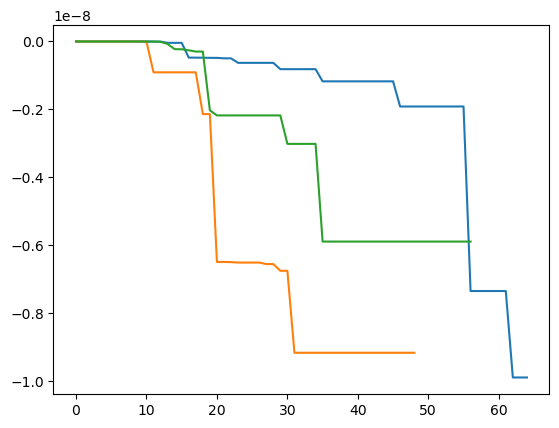

In [ ]:
for i in range(len(energies_ws)):
    plt.plot(energies_ws[i])


In [3]:
# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 1000 # number of simulations
final_hinges_gd, final_es_gd, energies_gd = sim.sim_many(nsim, 'greedy descent',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False)
final_hinges_mc, final_es_mc, energies_mc = sim.sim_many(nsim, 'monte carlo',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False)
final_hinges_ws, final_es_ws, energies_ws = sim.sim_many(nsim, 'weighted sync',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False)

In [16]:
def averageEnergies(arr):
    max_len = max(len(a) for a in arr)

    padded = np.full((len(arr), max_len), np.nan)

    for j, a in enumerate(arr):
        padded[j, :len(a)] = a

    means = np.nanmedian(padded, axis=0)

    return means

Text(0, 0.5, 'Energy (J)')

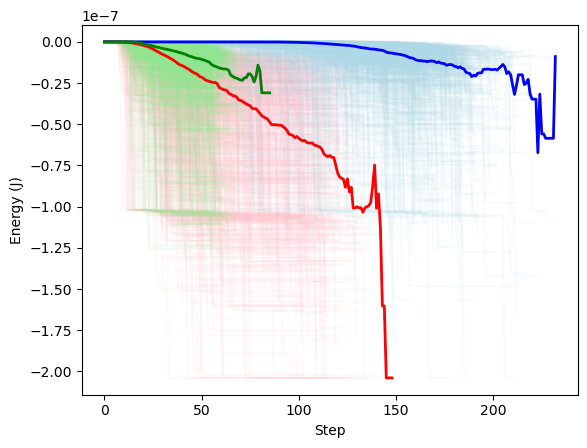

In [17]:
for i in range(len(energies_gd)):
    plt.plot(energies_gd[i],c='pink',alpha=0.1)

for i in range(len(energies_mc)):
    plt.plot(energies_mc[i],c='lightblue', alpha=0.1)

for i in range(len(energies_ws)):
    plt.plot(energies_ws[i],c='lightgreen', alpha = 0.1)

plt.plot(averageEnergies(energies_gd),c='r',lw=2)
plt.plot(averageEnergies(energies_mc),c='b',lw=2)
plt.plot(averageEnergies(energies_ws),c='g',lw=2)

plt.xlabel("Step")
plt.ylabel("Energy (J)")

Text(0, 0.5, 'Energy (J)')

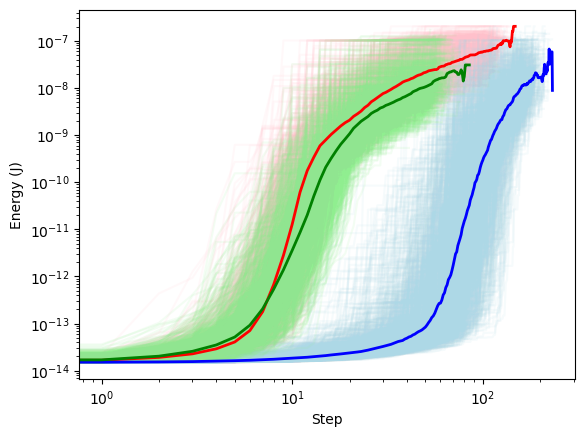

In [18]:
for i in range(len(energies_gd)):
    plt.loglog(np.abs(energies_gd[i]),c='pink',alpha=0.1)

for i in range(len(energies_mc)):
    plt.loglog(np.abs(energies_mc[i]),c='lightblue',alpha=0.1)

for i in range(len(energies_ws)):
    plt.loglog(np.abs(energies_ws[i]),c='lightgreen',alpha=0.1)

plt.loglog(np.abs(averageEnergies(energies_gd)),c='r',lw=2)
plt.loglog(np.abs(averageEnergies(energies_mc)),c='b',lw=2)
plt.loglog(np.abs(averageEnergies(energies_ws)),c='g',lw=2)

plt.xlabel("Step")
plt.ylabel("Energy (J)")

Text(0, 0.5, 'Energy (J)')

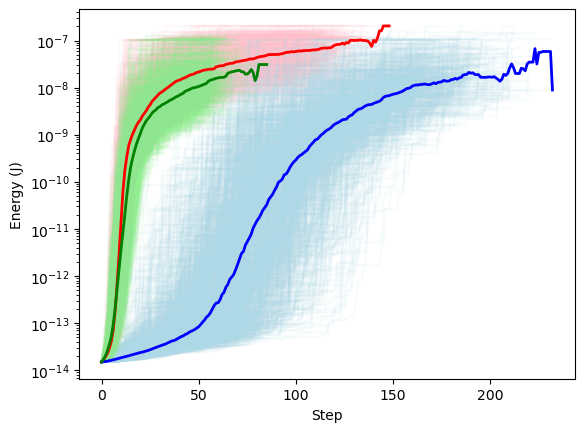

In [19]:
for i in range(len(energies_gd)):
    plt.semilogy(np.abs(energies_gd[i]),c='pink',alpha=0.1)

for i in range(len(energies_mc)):
    plt.semilogy(np.abs(energies_mc[i]),c='lightblue',alpha=0.1)

for i in range(len(energies_ws)):
    plt.semilogy(np.abs(energies_ws[i]),c='lightgreen',alpha=0.1)

plt.semilogy(np.abs(averageEnergies(energies_gd)),c='r',lw=2)
plt.semilogy(np.abs(averageEnergies(energies_mc)),c='b',lw=2)
plt.semilogy(np.abs(averageEnergies(energies_ws)),c='g',lw=2)

plt.xlabel("Step")
plt.ylabel("Energy (J)")

Text(0.5, 0, 'Energy')

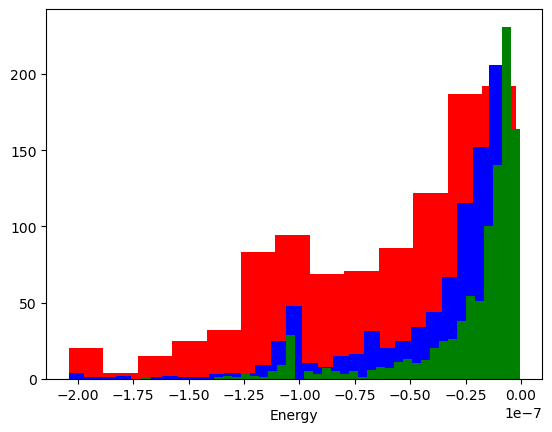

In [20]:
plt.hist(final_es_gd,bins='auto',color="red")
plt.hist(final_es_mc,bins='auto',color="blue")
plt.hist(final_es_ws,bins='auto',color="green")

plt.xlabel("Energy")